In [ ]:
!pip install geopandas rasterio scikit-learn folium matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 48.2 MB/s eta 0:00:00


In [ ]:
import ee # Import the earthengine library and assign it to the variable 'ee'

# Authenticate and initialize GEE
ee.Authenticate()
ee.Initialize(project='lluktarn')

In [ ]:
# กำหนดขอบเขตจังหวัดเชียงใหม่จาก GEE
th_provinces = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level1") \
    .filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))
chiangmai = th_provinces.filter(ee.Filter.eq('ADM1_NAME', 'Chiang Mai'))

In [ ]:
# ตรวจสอบ
print(chiangmai.getInfo())

# โหลด Sentinel-2 ล่าสุดที่มี cloud cover น้อย
sentinel = (ee.ImageCollection('COPERNICUS/S2_SR')
            .filterBounds(chiangmai)
            .filterDate('2022-01-01', '2022-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .median()
            .clip(chiangmai))

{'type': 'FeatureCollection', 'columns': {'ADM0_CODE': 'Integer', 'ADM0_NAME': 'String', 'ADM1_CODE': 'Integer', 'ADM1_NAME': 'String', 'DISP_AREA': 'String', 'EXP1_YEAR': 'Integer', 'STATUS': 'String', 'STR1_YEAR': 'Integer', 'Shape_Area': 'Float', 'Shape_Leng': 'Float', 'system:index': 'String'}, 'version': 1701682755394127, 'id': 'FAO/GAUL_SIMPLIFIED_500m/2015/level1', 'properties': {'system:asset_size': 80042928}, 'features': [{'type': 'Feature', 'geometry': {'type': 'GeometryCollection', 'geometries': [{'type': 'LineString', 'coordinates': [[98.09236474607965, 17.633674030683338], [98.09011899034472, 17.633674030683334]]}, {'type': 'LineString', 'coordinates': [[98.19566950988649, 17.977274684015654], [98.19566950988649, 17.979520413862808]]}, {'type': 'LineString', 'coordinates': [[98.49435499471102, 17.29007340323895], [98.49210926689747, 17.29007340323879]]}, {'type': 'LineString', 'coordinates': [[99.35223371337631, 18.574645645491916], [99.3522337133763, 18.572399927884764]]}

/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


In [ ]:
# คำนวณ NDVI
ndvi = sentinel.normalizedDifference(['B8', 'B4']).rename('NDVI')

In [ ]:
# รวม Band ที่ใช้
image = sentinel.select(['B4', 'B3', 'B8', 'B11']).addBands(ndvi)

In [ ]:
# แสดงผลด้วยแผนที่
Map = geemap.Map(center=[18.7883, 98.9853], zoom=9)
Map.addLayer(image, {'bands': ['B4', 'B3', 'B8'], 'min':0, 'max':3000}, 'Sentinel RGB')
Map.addLayer(ndvi, {'min': 0, 'max': 1, 'palette': ['white', 'green']}, 'NDVI')
Map

Map(center=[18.7883, 98.9853], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDa…

In [ ]:
# สร้างจุดตัวอย่างในเชียงใหม่
import pandas as pd

data = {
    "latitude": [18.7961, 18.7885, 18.7982, 18.7872, 18.7909, 18.7924, 18.8005, 18.7991, 18.7936],
    "longitude": [98.9796, 98.9850, 98.9821, 98.9835, 98.9843, 98.9804, 98.9772, 98.9810, 98.9861],
    "label": ["green_area", "green_area", "green_area",
              "urban_area", "urban_area", "urban_area",
              "water_body", "water_body", "water_body"]
}

In [ ]:
df = pd.DataFrame(data)
df.to_csv("sample_points_chiangmai.csv", index=False)
print("✅ สร้างไฟล์ sample_points_chiangmai.csv เรียบร้อยแล้ว!")
from google.colab import files
files.download("sample_points_chiangmai.csv")

✅ สร้างไฟล์ sample_points_chiangmai.csv เรียบร้อยแล้ว!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# สร้าง GeoDataFrame
import geopandas as gpd
from shapely.geometry import Point

samples = pd.read_csv('sample_points_chiangmai.csv')
geometry = [Point(xy) for xy in zip(samples.longitude, samples.latitude)]
gdf = gpd.GeoDataFrame(samples, geometry=geometry, crs='EPSG:4326')
gdf.head()

,latitude,longitude,label,geometry
0,18.7961,98.9796,green_area,POINT (98.9796 18.7961)
1,18.7885,98.9850,green_area,POINT (98.985 18.7885)
2,18.7982,98.9821,green_area,POINT (98.9821 18.7982)
3,18.7872,98.9835,urban_area,POINT (98.9835 18.7872)
4,18.7909,98.9843,urban_area,POINT (98.9843 18.7909)


In [ ]:
# แปลงจุดเป็น FeatureCollection ของ GEE และสุ่มตัวอย่างข้อมูล
import ee
import geemap

ee.Initialize(project='lluktarn')

samples = pd.read_csv("sample_points_chiangmai.csv")

In [ ]:
def row_to_ee_feature(row):
    return ee.Feature(ee.Geometry.Point([row["longitude"], row["latitude"]]), {"label": row["label"]})

ee_features = [row_to_ee_feature(row) for idx, row in samples.iterrows()]
ee_fc = ee.FeatureCollection(ee_features)

sampled = image.sampleRegions(
    collection=ee_fc,
    properties=['label'],
    scale=10,
    geometries=True
)

In [ ]:
geemap.ee_export_vector(sampled, filename="sampled_points.shp")
gdf = gpd.read_file("sampled_points.shp")
gdf.head()

Generating URL ...
Please wait ...
Data downloaded to /content/sampled_points.shp


,B3,B11,B4,B8,label,NDVI,geometry
0,2354.0,3935.0,2506.0,2708.0,green_area,0.038742,POINT (98.97957 18.79612)
1,2016.0,3341.0,2062.0,3348.0,green_area,0.237708,POINT (98.98496 18.78849)
2,2086.0,3770.0,2000.0,4022.0,green_area,0.335769,POINT (98.98208 18.79819)
3,2036.0,3581.0,2100.0,2780.0,urban_area,0.139344,POINT (98.98352 18.78723)
4,1730.0,3285.0,1656.0,2808.0,urban_area,0.258065,POINT (98.98433 18.79091)


In [ ]:
# เตรียมข้อมูลสำหรับการ Train
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['B4', 'B3', 'B8', 'B11', 'NDVI']
X = gdf[features]
y = gdf['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# สร้างโมเดลและค้นหาพารามิเตอร์ที่ดีที่สุด
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=2, n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


Accuracy: 0.3333333333333333

Classification Report:
               precision    recall  f1-score   support

  green_area       0.00      0.00      0.00         1
  urban_area       0.00      0.00      0.00         1
  water_body       1.00      1.00      1.00         1

    accuracy                           0.33         3
   macro avg       0.33      0.33      0.33         3
weighted avg       0.33      0.33      0.33         3



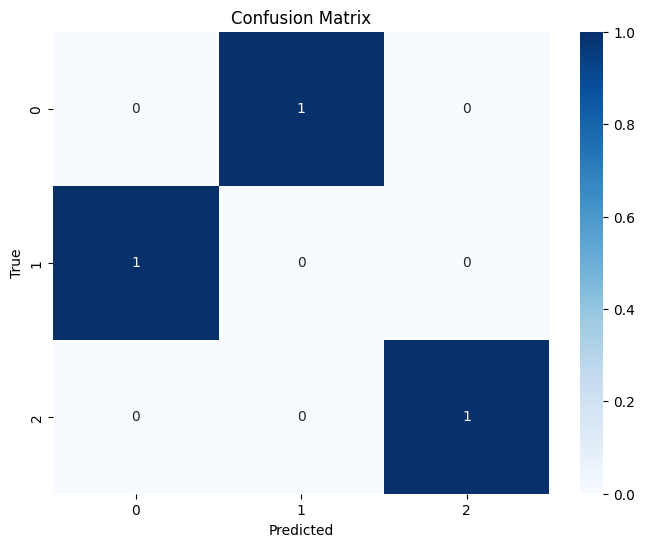

In [ ]:
# ประเมินผล
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = grid.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# เพิ่ม prediction ลงใน gdf
gdf['prediction'] = grid.predict(scaler.transform(gdf[features]))

# สร้างแผนที่ Folium
import folium

m = folium.Map(location=[18.7883, 98.9853], zoom_start=9)

def get_color(row):
    if row['label'] == row['prediction']:
        return 'green'
    else:
        return 'red'

for idx, row in gdf.iterrows():
    color = get_color(row)
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        popup=f"Label: {row['label']} / Pred: {row['prediction']}",
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

In [ ]:
# คำนวณความแม่นยำ
accuracy = accuracy_score(gdf['label'], gdf['prediction'])
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(gdf['label'], gdf['prediction'])
print("Confusion Matrix:")
print(cm)

# Classification Report
report = classification_report(gdf['label'], gdf['prediction'])
print("Classification Report:")
print(report)

Accuracy: 0.7778
Confusion Matrix:
[[2 1 0]
 [1 2 0]
 [0 0 3]]
Classification Report:
              precision    recall  f1-score   support

  green_area       0.67      0.67      0.67         3
  urban_area       0.67      0.67      0.67         3
  water_body       1.00      1.00      1.00         3

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9



คำถามท้าย LAB
1. ทำไมการเลือก Features ที่เหมาะสมจึงสำคัญใน Machine Learning?

 การเลือก Features ที่เหมาะสมจะช่วยให้แบบจำลองเรียนรู้ข้อมูลได้ดีขึ้นและลดปัญหา overfitting หรือ noise ที่ไม่จำเป็น การใช้เฉพาะ Features ที่มีความสัมพันธ์กับ Target Class จะช่วยเพิ่มประสิทธิภาพของแบบจำลอง ทำให้ความแม่นยำสูงขึ้น ใช้เวลาเทรนสั้นลง และผลลัพธ์มีความน่าเชื่อถือมากกว่า


---


2. เปรียบเทียบระหว่าง Random Forest และ SVM ในบริบทของปัญหานี้
- Random Forest เหมาะกับข้อมูลที่มีหลายมิติและมี noise เพราะสามารถจัดการกับข้อมูลปริมาณมากได้ดี ใช้งานง่าย ปรับพารามิเตอร์ไม่ซับซ้อน และให้ผลลัพธ์ที่แม่นยำ นอกจากนี้ยังสามารถอธิบายความสำคัญของแต่ละ feature ได้ด้วย
- SVM ให้ผลลัพธ์แม่นยำสูงเช่นกัน โดยเฉพาะเมื่อข้อมูลสามารถแบ่งได้ชัดเจน แต่ไม่เหมาะกับข้อมูลขนาดใหญ่มากเพราะใช้เวลาฝึกนาน และต้องเลือก kernel กับพารามิเตอร์อย่างระมัดระวัง
สรุป Random Forest เหมาะสมกว่า เพราะรับมือกับข้อมูลภาพถ่ายดาวเทียมที่มีความซับซ้อนและหลากหลายได้ดีกว่า SVM

---



3. การใช้ NDVI เพียงอย่างเดียวเพียงพอสำหรับจำแนกประเภทพื้นที่หรือไม่? ทำไม?

   NDVI อย่างเดียว ไม่เพียงพอ สำหรับจำแนกประเภทพื้นที่ เพราะ NDVI บอกแค่ระดับความเขียวของพืชพรรณ              ไม่สามารถแยกประเภทที่มี NDVI ใกล้เคียงกันได้ เช่น ป่าไม้ vs พื้นที่เกษตรกรรม ไม่สามารถแยกพื้นที่ไม่มีพืช เช่น เมือง หรือแหล่งน้ำ ได้ดี ควรใช้ NDVI ร่วมกับ Band อื่น ๆ เช่น Red, Green, SWIR เพื่อให้จำแนกประเภทได้แม่นยำยิ่งขึ้น


---

4. หากต้องการเพิ่มความแม่นยำของแบบจำลอง ควรทำอย่างไร?

- เลือก Features ที่มีความสำคัญต่อเป้าหมาย
- เพิ่มข้อมูลตัวอย่าง (sampling หรือใช้ข้อมูลเพิ่ม)
- ปรับพารามิเตอร์ของโมเดล (เช่น Grid Search)
- ใช้เทคนิค Ensemble (เช่น RF, XGBoost)
- ทำ Data Augmentation (เช่น ขยาย sample ด้วย jittering)
- ลด noise ในข้อมูล เช่น ทำ Filter NDVI หรือปรับ preprocessing


---

5. ปัจจัยใดที่อาจทำให้แบบจำลองจำแนกประเภทของพื้นที่ผิดพลาด?
- ข้อมูลมี noise หรือ cloud cover ในภาพถ่ายดาวเทียม
- พื้นที่มีลักษณะใกล้เคียงกัน เช่น ป่าเตี้ยกับพื้นที่เกษตร
- จุดตัวอย่างไม่กระจายทั่วพื้นที่ หรือไม่เพียงพอ
- Feature ที่เลือกไม่แยกประเภทได้ดี



